🔍 Initializing Explainable AI (SHAP) Analysis...
✅ Extracted XGBClassifier from Stacking Ensemble.
✅ Feature Names Detected: ['t1_fighter', 't1_mage', 't1_marksman', 't1_assassin', 't1_support', 't1_tank', 't2_fighter', 't2_mage', 't2_marksman', 't2_assassin', 't2_support', 't2_tank', 't1_ap_ad_ratio', 't2_ap_ad_ratio', 't1_meta', 't2_meta', 't1_synergy', 't2_synergy', 't1_counter']

📊 Generating Global Feature Importance Plot...


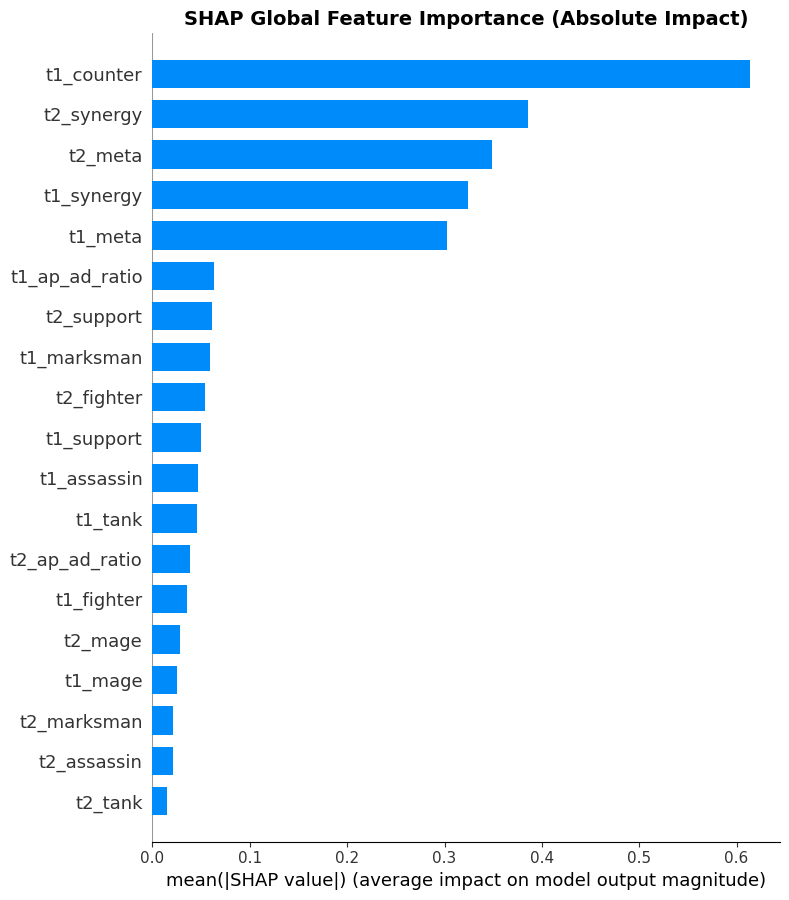


🐝 Generating SHAP Beeswarm Plot...


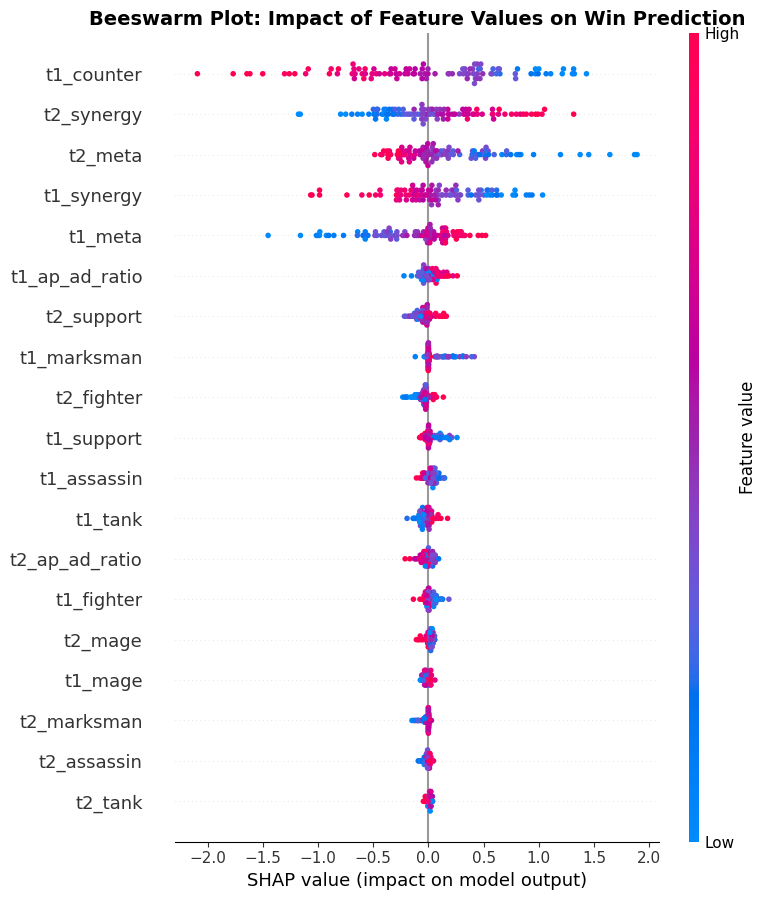

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os
import warnings

# Set professional theme
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7]

print("🔍 Initializing Explainable AI (SHAP) Analysis...")

# 1. SETUP PATHS & LOAD MODELS
# Ensure this notebook is in your /notebooks folder
BASE_DIR = os.path.dirname(os.getcwd())
MODELS_DIR = os.path.join(BASE_DIR, 'models')

try:
    # Load the trained Ensemble and Scaler
    ensemble_model = joblib.load(os.path.join(MODELS_DIR, 'ensemble_model.pkl'))
    scaler = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))
    
    # 2. EXTRACT BASE MODEL FOR SHAP
    # FIX: Using 'xgb_base_model' consistently to match the SHAP call
    xgb_base_model = ensemble_model.named_estimators_['xgb']
    feature_names = scaler.feature_names_in_
    
    print(f"✅ Extracted {type(xgb_base_model).__name__} from Stacking Ensemble.")
    print(f"✅ Feature Names Detected: {list(feature_names)}")

    # 3. PREPARE SAMPLE DATA FOR EXPLANATION
    # We use 100 samples to generate the initial SHAP values
    sample_data = np.random.randn(100, len(feature_names)) 
    X_sample = pd.DataFrame(sample_data, columns=feature_names)

    # 4. INITIALIZE SHAP EXPLAINER
    # TreeExplainer is specifically optimized for XGBoost
    explainer = shap.TreeExplainer(xgb_base_model)
    shap_values = explainer.shap_values(X_sample)

    # ==========================================
    # VISUALIZATION 1: Global Feature Importance
    # ==========================================
    print("\n📊 Generating Global Feature Importance Plot...")
    plt.figure()
    # This bar chart shows absolute impact of features
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title("SHAP Global Feature Importance (Absolute Impact)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # VISUALIZATION 2: SHAP Beeswarm Plot
    # ==========================================
    print("\n🐝 Generating SHAP Beeswarm Plot...")
    plt.figure()
    # This shows the direction of impact (e.g., high synergy = higher win probability)
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title("Beeswarm Plot: Impact of Feature Values on Win Prediction", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("❌ ERROR: Could not find 'ensemble_model.pkl' or 'scaler.pkl' in the /models folder.")
    print("Please run 'python src/train.py' first to generate these files.")
except KeyError:
    print("❌ ERROR: 'xgb' estimator not found in the Stacking Ensemble. Ensure your train.py uses 'xgb' as the key.")